# Data Set information
Calculated all protein single chain length by using Biopython from raw data(downloaded 176,676 PDB structures from Protein Data Bank in March 2021) and stored some information in PDBsingleChain_len_csv.csv. 

Calculated all human single chain length by using Biopython from raw data(downloaded 23,391 PDB structures from [Alphafold Homo sapiens](https://alphafold.ebi.ac.uk/download)) and stored some information in AlphaFoldHuman_len_csv.csv.    

PDBsingleChain_len_csv contains 63036 protein single chain structures with 3 attributes.  
AlphaFoldHuman_len_csv contains 20516 protein single chain structures with 3 attributes.   
* structure_id: PDB id    
* chain_id: chain id  
* length: protein chain length   

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

## Getting Data

In [3]:
pdb_df=pd.read_csv("D:/ma/PDB project/data/structure_db/PDBsingleChain_len_csv.csv")
alpha_df=pd.read_csv("D:/ma/PDB project/data/structure_db/AlphaFoldHuman_len_csv.csv")

In [18]:
pdb_df.head(4)

,structure_id,chain_id,length
0,101m,A,154
1,102l,A,163
2,102m,A,154
3,103l,A,159


In [19]:
alpha_df.head(4)

,structure_id,chain_id,length
0,AF-A0A024R1R8-F1-model_v1,A,64
1,AF-A0A024RBG1-F1-model_v1,A,181
2,AF-A0A024RCN7-F1-model_v1,A,75
3,AF-A0A075B6H5-F1-model_v1,A,130


In [16]:
print('pdb shape:{0}, Alpha shape:{1}'.format(pdb_df.shape,alpha_df.shape))


pdb shape:(63036, 3), Alpha shape:(20516, 3)


In [25]:
pdb_df.describe()

,length
count,63036.000000
mean,257.388365
std,182.364342
min,1.000000
25%,129.000000
50%,235.000000
75%,330.000000
max,4350.000000


In [24]:
alpha_df.describe()

,length
count,20516.000000
mean,529.116299
std,417.535514
min,16.000000
25%,248.000000
50%,412.000000
75%,669.000000
max,2699.000000


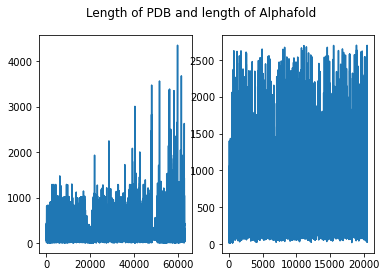

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('Length of PDB and length of Alphafold')
ax1.plot(pdb_df.length)
ax2.plot(alpha_df.length)

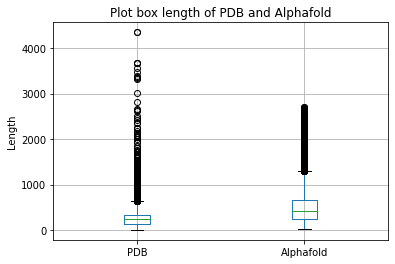

In [5]:
plotBoxTwoElement(pdb_df.length,alpha_df.length,'PDB','Alphafold','Length','Plot box length of PDB and Alphafold')

In [8]:
def removeOutlier(data_df,data):
    q1 = data.quantile(0.25)
    q3  = data.quantile(0.75)

    iqr= np.round(q3-q1,2)
    upper_bound=q3+(1.5*iqr)
    lower_bound=q1-(1.5*iqr)
    pdb_filtered = data_df[(data < upper_bound) & (data > lower_bound)]
    return pdb_filtered

In [9]:
pdb=removeOutlier(pdb_df,pdb_df.length)
alpha=removeOutlier(alpha_df,alpha_df.length)

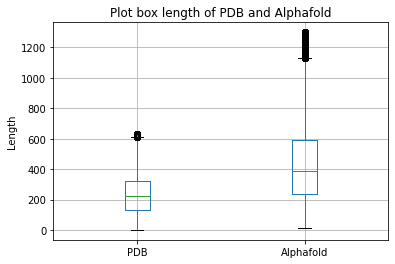

In [10]:
plotBoxTwoElement(pdb.length,alpha.length,'PDB','Alphafold','Length','Plot box length of PDB and Alphafold')

In [1]:
def plotBoxTwoElement(data1,data2,y1,y2,x,title):
    data_1=pd.Series(np.array(data1))
    data_2 = pd.Series(np.array(data2))
    data=pd.DataFrame({y1:data_1,y2:data_2})
    data.boxplot()
    plt.ylabel(x)
    plt.title(title)
    plt.show()

In [7]:
def plotTwoElementRatio(data1,data2,title,featureName):
    density1, bins1, _ = plt.hist(data1, alpha=0.5, weights=np.ones(len(data1)) / len(data1),label='PDB total:' + str(len(data1)))
    density2, bins2, _ = plt.hist(data2, alpha=0.5, weights=np.ones(len(data2)) / len(data2),label='AlphaFold human total:' + str(len(data2)))
    plt.title(title)
    plt.xlabel(featureName)
    plt.ylabel('Ratio')
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
    plt.legend()
    plt.show()

### result
Obviously, the coverage of PDB and Alphafold are different. After around 150, the proportion of Alphafold is much higher than PDB. Alphafold did a really good job in long length chain. They have the different pattern. 

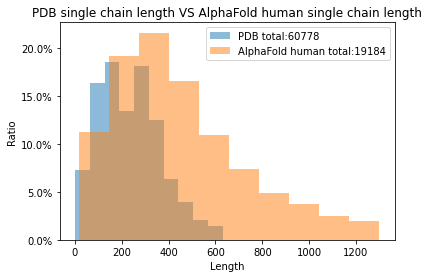

In [8]:
plotTwoElementRatio(pdb['length'],alpha['length'],"PDB single chain length VS AlphaFold human single chain length",'Length')